In [1]:
import torch

# Sprawdź, czy PyTorch wykrywa GPU
if torch.cuda.is_available():
    print("PyTorch widzi GPU!")
    print(f"Nazwa karty graficznej: {torch.cuda.get_device_name(0)}")
    print(f"Liczba dostępnych GPU: {torch.cuda.device_count()}")
else:
    print("PyTorch nie widzi GPU.")


PyTorch widzi GPU!
Nazwa karty graficznej: NVIDIA GeForce GTX 960
Liczba dostępnych GPU: 1


In [2]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

In [2]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
torch.cuda.reset_accumulated_memory_stats()
torch.cuda.synchronize()
torch.cuda.empty_cache()

In [3]:
cd /mnt/Inzynierka

/mnt/Inzynierka


In [4]:
from ultralytics import YOLO

# Create a new YOLO model from scratch
#model = YOLO("")

# Load a pretrained YOLO model (recommended for training)
model = YOLO("yolov8n.pt")

# Train the model using the 'data.yaml' dataset for 20 epochs
results = model.train(data="/mnt/Inzynierka/yolov8_3klasy_calosc/data.yaml", epochs=50, batch=4)

# Evaluate the model's performance on the validation set
results = model.val()

# Perform object detection on an image using the model
results = model("/mnt/Inzynierka/yolov8_3klasy_calosc/test/images/20241119_155900_4_jpg.rf.df5677423eeedfb64a949296071010b8.jpg")

# Export the model to ONNX format
success = model.export(format="onnx")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
New https://pypi.org/project/ultralytics/8.3.49 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.33 🚀 Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce GTX 960, 1986MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/mnt/Inzynierka/yolov8_3klasy_calosc/data.yaml, epochs=50, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train6, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False

100%|██████████| 755k/755k [00:00<00:00, 10.9MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /mnt/Inzynierka/yolov8_3klasy_calosc/train/labels... 2012 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2012/2012 [00:01<00:00, 2011.92it/s]


train: New cache created: /mnt/Inzynierka/yolov8_3klasy_calosc/train/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 143, len(boxes) = 62458. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


...

                   all        677      27447      0.761      0.466      0.536      0.326
         uklad_scalony        344       1519        0.7      0.703      0.726      0.506
           kondensator        563      12285      0.777      0.348      0.444      0.243
               opornik        622      13643      0.807      0.346      0.439      0.227
Speed: 0.5ms preprocess, 9.1ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/train6
Ultralytics 8.3.33 🚀 Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce GTX 960, 1986MiB)
Model summary (fused): 168 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /mnt/Inzynierka/yolov8_3klasy_calosc/valid/labels.cache... 677 images, 0 backgrounds, 0 corrupt: 100%|██████████| 677/677 [00:00<?, ?it/s]

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 34, len(boxes) = 27447. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 170/170 [00:13<00:00, 12.41it/s]


                   all        677      27447       0.76      0.467      0.537      0.326
         uklad_scalony        344       1519      0.697      0.704      0.726      0.506
           kondensator        563      12285      0.777      0.349      0.445      0.244
               opornik        622      13643      0.806      0.347       0.44      0.228
Speed: 0.6ms preprocess, 10.7ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to runs/detect/train62

image 1/1 /mnt/Inzynierka/yolov8_3klasy_calosc/test/images/20241119_155900_4_jpg.rf.df5677423eeedfb64a949296071010b8.jpg: 640x640 4 kondensators, 10.2ms
Speed: 1.9ms preprocess, 10.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Ultralytics 8.3.33 🚀 Python-3.8.10 torch-2.4.1+cu121 CPU (Intel Core(TM) i5-4460  3.20GHz)

PyTorch: starting from 'runs/detect/train6/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (6.0 MB)
requirements: Ultralytics requirements [

In [5]:
# Perform object detection on an image using the model
results = model("/mnt/Inzynierka/elementyv11_zbior2/test/images/pcb50rec1_jpg.rf.dfd49dfeca664db8956bf05c7a15c25e.jpg")

# Export the model to ONNX format
success = model.export(format="onnx")


image 1/1 /mnt/Inzynierka/elementyv11_zbior2/test/images/pcb50rec1_jpg.rf.dfd49dfeca664db8956bf05c7a15c25e.jpg: 640x640 7 0s, 2 3s, 19 4s, 4 6s, 12.8ms
Speed: 2.8ms preprocess, 12.8ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Ultralytics 8.3.33 🚀 Python-3.8.10 torch-2.4.1+cu121 CPU (Intel Core(TM) i5-4460  3.20GHz)

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 20, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.19.6
    Uninstalling protobuf-3.19.6:
      Successfully uninstalled protobuf-3.19.6

requirements: AutoUpdate success ✅ 17.6s, installed 3 packages: ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.17.0 

In [5]:
results = model(["/mnt/Inzynierka/yolov8_3klasy_z_dodatkami/test/images/20241119_160121_3_jpg.rf.eee8fef01d9a1ada49581ff4495665f2.jpg", "/mnt/Inzynierka/yolov8_3klasy_z_dodatkami/test/images/20241119_155945_8_jpg.rf.50da16a8b9930a45e78d741519a9d071.jpg"])


0: 640x640 1 opornik, 19.3ms
1: 640x640 4 kondensators, 10 oporniks, 19.3ms
Speed: 4.2ms preprocess, 19.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


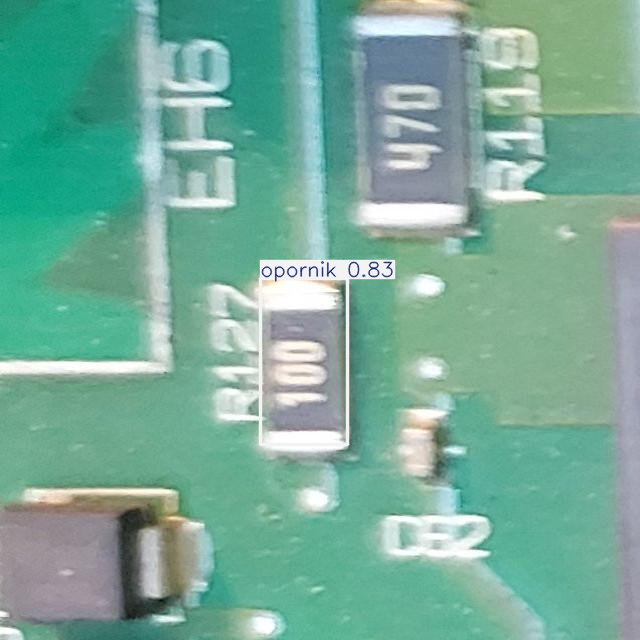

In [13]:
results[0].show()

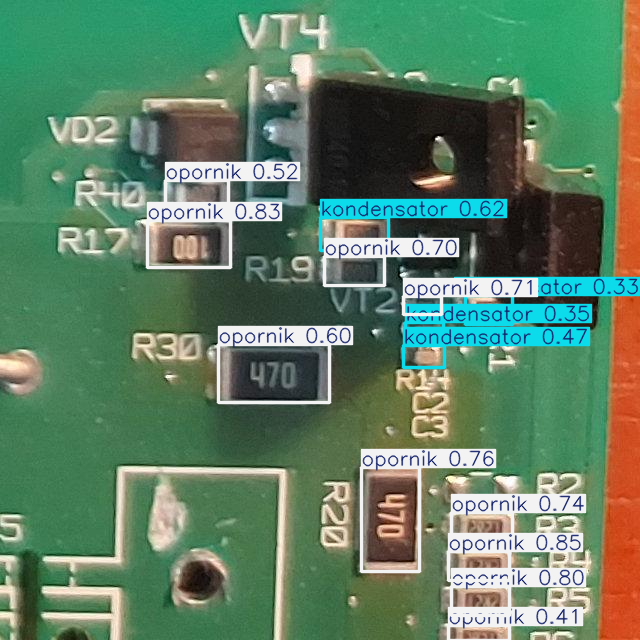

In [7]:
results[1].show()

In [8]:
results.extend(model(["/mnt/Inzynierka/yolov8_3klasy_z_dodatkami/test/images/20241119_155900_4_jpg.rf.df5677423eeedfb64a949296071010b8.jpg"]))


0: 640x640 4 kondensators, 1 opornik, 12.9ms
Speed: 2.3ms preprocess, 12.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


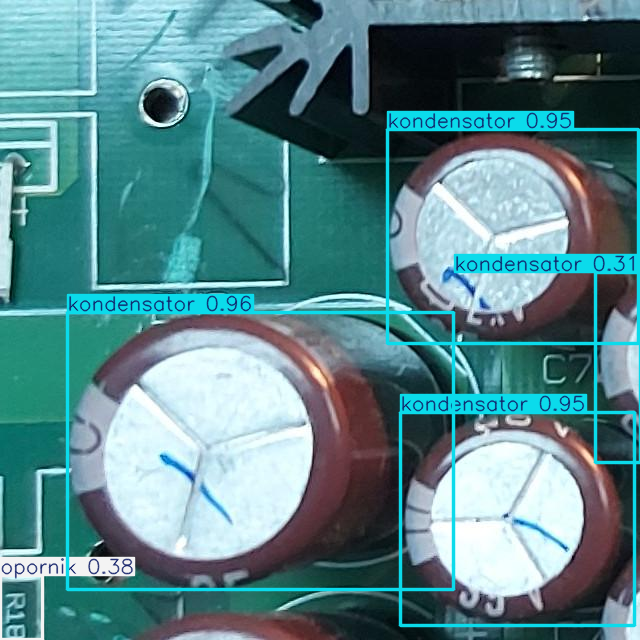

In [9]:
results[2].show()

In [10]:
results.extend(model(["/mnt/Inzynierka/yolov8_3klasy_z_dodatkami/test/images/PCBA_67_jpg.rf.7cfeb785270e623dcbe3132f90f8f5f7.jpg","/mnt/Inzynierka/yolov8_3klasy_z_dodatkami/test/images/PCBA_97_jpg.rf.875a2f4b2e2c0c0bbcab0a6c98b7805f.jpg"]))


0: 640x640 3 kondensators, 10 oporniks, 11.0ms
1: 640x640 5 uklad_scalonys, 9 kondensators, 18 oporniks, 11.0ms
Speed: 2.2ms preprocess, 11.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


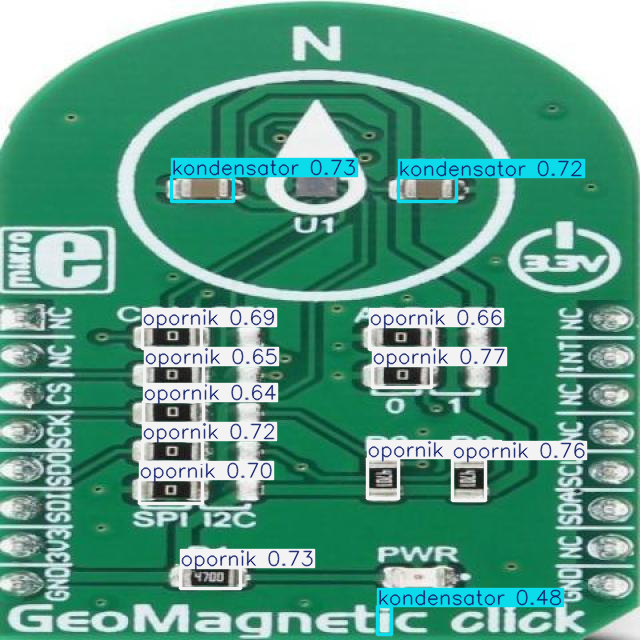

In [11]:
results[3].show()

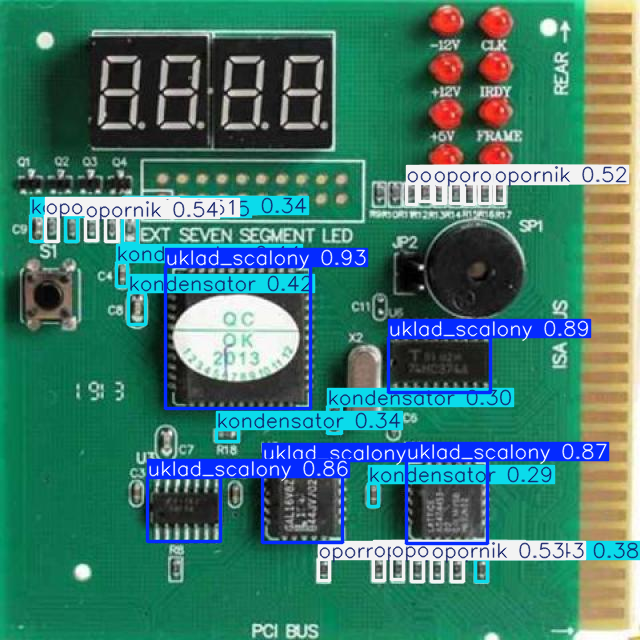

In [12]:
results[4].show()